# 🏭 RL Job Shop Scheduling Training

### Design
- **Action = task selection only** (`Discrete(MAX_TASKS)`)
- **Machine = auto-selected** → always picks the machine that finishes earliest
- Guarantees fastest machine is ALWAYS chosen

### Parameters
| Param | Value | Reason |
|---|---|---|
| `n_orders` | 10 | Production orders per episode |
| `quantity` | 10-50 | Units per PO (variable) |
| `MAX_TASKS` | 250 | 10 PO × 23 tasks = 230 + buffer |
| `MAX_MACHINES` | 50 | 40 work centers + buffer |
| `horizon_days` | 60 | Enough for qty up to 50 |
| `timesteps` | 300,000 | Training budget |
| `action_space` | 250 | Task-only (not task × machine) |

In [1]:
%pip install gymnasium stable-baselines3 numpy matplotlib torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 3.7 MB/s eta 0:00:00


In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Set
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Data Structures

In [3]:
@dataclass
class ShiftWindow:
    start_min: int
    end_min: int

@dataclass
class WorkCenterConfig:
    id: int
    name: str
    operation_id: int
    capacity_per_hour: float
    workers_required: int = 1
    cost_per_hour: float = 0.0
    shifts: Dict[int, List[ShiftWindow]] = field(default_factory=dict)

@dataclass
class JobTask:
    job_id: int
    task_idx: int
    operation_id: int
    setup_time: int
    quantity: int
    predecessors: List[int] = field(default_factory=list)

@dataclass
class ScheduledTask:
    job_id: int
    task_idx: int
    machine_id: int
    start: int
    end: int

## Problem Generator (10 PO, qty 10-50)

In [4]:
class CarFactoryGenerator:
    """
    Generator for 10 PO with qty 10-50.
    Shift categories match SQL data exactly.
    """
    PAINT_SHOP = {'WC-CLEAN-01', 'WC-PAINT-PREP', 'WC-PAINT-BOOTH-01',
                  'WC-PAINT-BOOTH-02', 'WC-CLEAR-COAT', 'WC-PAINT-CURE', 'WC-POLISH-01'}
    QC_TESTING = {'WC-QC-BODY-01', 'WC-QC-BODY-02', 'WC-QC-PAINT', 'WC-QC-FINAL',
                  'WC-TEST-WATER', 'WC-TEST-ROAD-01', 'WC-TEST-ROAD-02'}

    def __init__(self, n_orders=10, seed=None):
        self.n_orders = n_orders
        self.rng = np.random.RandomState(seed)

    def _get_shifts(self, name):
        shifts = {}
        if name in self.PAINT_SHOP:
            for d in range(1, 7):  # Mon-Sat
                shifts[d] = [ShiftWindow(480, 960), ShiftWindow(960, 1440)]
        elif name in self.QC_TESTING:
            for d in range(1, 7):  # Mon-Sat, Shift A only
                shifts[d] = [ShiftWindow(480, 960)]
        else:
            for d in range(1, 6):  # Mon-Fri
                shifts[d] = [ShiftWindow(480, 960), ShiftWindow(960, 1440)]
        return shifts

    def generate(self):
        wc_sql_data = [
            (1, 'WC-STAMP-01', 120), (2, 'WC-STAMP-02', 90),
            (3, 'WC-TRIM-01', 60),
            (4, 'WC-WELD-01', 10), (5, 'WC-WELD-02', 6),
            (6, 'WC-BODY-ASSY', 6), (7, 'WC-DOOR-ASSY', 20),
            (8, 'WC-CLEAN-01', 12), (9, 'WC-PAINT-PREP', 10),
            (10, 'WC-PAINT-BOOTH-01', 8), (11, 'WC-PAINT-BOOTH-02', 6),
            (12, 'WC-CLEAR-COAT', 8), (13, 'WC-PAINT-CURE', 8), (14, 'WC-POLISH-01', 10),
            (15, 'WC-ENGINE-ASSY-01', 4), (16, 'WC-ENGINE-ASSY-02', 3), (17, 'WC-ENG-TEST', 8),
            (18, 'WC-TRANS-ASSY', 6), (19, 'WC-TRANS-TEST', 10),
            (20, 'WC-CHASSIS-WELD-01', 6), (21, 'WC-CHASSIS-WELD-02', 4),
            (22, 'WC-SUSPENSION', 12), (23, 'WC-WHEEL-MOUNT', 20),
            (24, 'WC-FINAL-01', 4), (25, 'WC-FINAL-02', 3),
            (26, 'WC-ENG-INST', 6), (27, 'WC-TRANS-INST', 8),
            (28, 'WC-TRIM-INT-01', 8), (29, 'WC-TRIM-INT-02', 6),
            (30, 'WC-ELEC-INST', 10), (31, 'WC-GLASS-INST', 15), (32, 'WC-FLUID-FILL', 20),
            (33, 'WC-QC-BODY-01', 12), (34, 'WC-QC-BODY-02', 8),
            (35, 'WC-QC-PAINT', 10), (36, 'WC-QC-FINAL', 6),
            (37, 'WC-TEST-WATER', 12),
            (38, 'WC-TEST-ROAD-01', 8), (39, 'WC-TEST-ROAD-02', 6),
            (40, 'WC-DETAIL', 10)
        ]

        work_centers = {}
        wc_name_to_id = {}
        for idx, (sql_id, name, cap) in enumerate(wc_sql_data):
            wc_name_to_id[name] = idx
            work_centers[idx] = WorkCenterConfig(
                id=idx, name=name, operation_id=0,
                capacity_per_hour=float(cap), workers_required=2,
                shifts=self._get_shifts(name)
            )

        def get_wcs(names):
            return [wc_name_to_id[n] for n in names]

        routing_body = [
            (1010, get_wcs(['WC-STAMP-01', 'WC-STAMP-02']), 45, []),
            (1020, get_wcs(['WC-TRIM-01']), 10, [1010]),
            (1030, get_wcs(['WC-WELD-01', 'WC-WELD-02']), 35, [1020]),
            (1040, get_wcs(['WC-BODY-ASSY']), 25, [1030]),
            (1050, get_wcs(['WC-QC-BODY-01', 'WC-QC-BODY-02']), 10, [1040])
        ]
        routing_chassis = [
            (2010, get_wcs(['WC-CHASSIS-WELD-01', 'WC-CHASSIS-WELD-02']), 30, []),
            (2020, get_wcs(['WC-SUSPENSION']), 20, [2010])
        ]
        routing_engine = [
            (3010, get_wcs(['WC-ENGINE-ASSY-01', 'WC-ENGINE-ASSY-02']), 30, []),
            (3020, get_wcs(['WC-ENG-TEST']), 10, [3010])
        ]
        routing_trans = [
            (4010, get_wcs(['WC-TRANS-ASSY']), 25, []),
            (4020, get_wcs(['WC-TRANS-TEST']), 10, [4010])
        ]
        routing_final = [
            (10, get_wcs(['WC-FINAL-01', 'WC-FINAL-02']), 30, []),
            (20, get_wcs(['WC-ENG-INST']), 20, [10]),
            (30, get_wcs(['WC-TRANS-INST']), 15, [20]),
            (40, get_wcs(['WC-TRIM-INT-01', 'WC-TRIM-INT-02']), 25, [30]),
            (50, get_wcs(['WC-ELEC-INST']), 30, [30]),
            (60, get_wcs(['WC-GLASS-INST']), 20, [40, 50]),
            (70, get_wcs(['WC-WHEEL-MOUNT']), 10, [60]),
            (80, get_wcs(['WC-FLUID-FILL']), 15, [70]),
            (90, get_wcs(['WC-TEST-WATER']), 10, [80]),
            (100, get_wcs(['WC-QC-FINAL']), 15, [90]),
            (110, get_wcs(['WC-TEST-ROAD-01', 'WC-TEST-ROAD-02']), 10, [100]),
            (120, get_wcs(['WC-DETAIL']), 10, [110])
        ]

        op_to_wc = {}
        all_routings = routing_body + routing_chassis + routing_engine + routing_trans + routing_final
        for op_id, wcs, _, _ in all_routings:
            op_to_wc[op_id] = wcs

        jobs = []
        for i in range(self.n_orders):
            qty = int(self.rng.randint(10, 51))  # 10-50 units per PO
            job_tasks = []
            current_task_idx = 0
            op_id_to_task_idx = {}

            def add_routing_tasks(routing):
                nonlocal current_task_idx
                for op_id, _, setup_time, preds_op_ids in routing:
                    preds_indices = [op_id_to_task_idx[p] for p in preds_op_ids if p in op_id_to_task_idx]
                    task = JobTask(job_id=i, task_idx=current_task_idx,
                                  operation_id=op_id, setup_time=setup_time,
                                  quantity=qty, predecessors=preds_indices)
                    job_tasks.append(task)
                    op_id_to_task_idx[op_id] = current_task_idx
                    current_task_idx += 1

            add_routing_tasks(routing_body)
            add_routing_tasks(routing_chassis)
            add_routing_tasks(routing_engine)
            add_routing_tasks(routing_trans)

            for op_id, _, setup_time, preds_op_ids in routing_final:
                preds_indices = [op_id_to_task_idx[p] for p in preds_op_ids if p in op_id_to_task_idx]
                if op_id == 10:
                    if 1050 in op_id_to_task_idx: preds_indices.append(op_id_to_task_idx[1050])
                    if 2020 in op_id_to_task_idx: preds_indices.append(op_id_to_task_idx[2020])
                if op_id == 20:
                    if 3020 in op_id_to_task_idx: preds_indices.append(op_id_to_task_idx[3020])
                if op_id == 30:
                    if 4020 in op_id_to_task_idx: preds_indices.append(op_id_to_task_idx[4020])
                task = JobTask(job_id=i, task_idx=current_task_idx, operation_id=op_id,
                              setup_time=setup_time, quantity=qty, predecessors=preds_indices)
                job_tasks.append(task)
                op_id_to_task_idx[op_id] = current_task_idx
                current_task_idx += 1

            jobs.append(job_tasks)

        return {
            'jobs': jobs, 'work_centers': work_centers, 'op_to_wc': op_to_wc,
            'holidays': set(), 'max_workers': 600, 'horizon_days': 60,
        }

## Environment (Task-Only Action + Auto Fastest Machine)

- `action_space = Discrete(250)` — model selects which task
- Machine is auto-selected: always the one with earliest completion

In [5]:
class JSSPEnv(gym.Env):
    """
    JSSP Environment - Task-Only Action Space.
    Action = which task to schedule next (Discrete(MAX_TASKS))
    Machine = auto-selected (fastest/earliest completion)
    """
    metadata = {"render_modes": ["human"]}

    def __init__(self, instance=None, generator_seed=None):
        super().__init__()
        self.generator = CarFactoryGenerator(seed=generator_seed)
        self.instance = instance
        self._setup_from_instance(instance or self.generator.generate())

        self.MAX_TASKS = 250
        self.MAX_MACHINES = 50
        self.action_space = spaces.Discrete(self.MAX_TASKS)

        task_feat = 7
        machine_feat = 4
        global_feat = 3
        obs_size = self.MAX_TASKS * task_feat + self.MAX_MACHINES * machine_feat + global_feat
        self.obs_size = obs_size
        self.task_feat = task_feat
        self.machine_feat = machine_feat
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32
        )

    def _setup_from_instance(self, instance):
        self.jobs = instance['jobs']
        self.work_centers = instance['work_centers']
        self.op_to_wc = instance['op_to_wc']
        self.holidays = instance['holidays']
        self.max_workers = instance['max_workers']
        self.horizon_days = instance['horizon_days']
        self.horizon_minutes = self.horizon_days * 1440
        self.all_tasks: List[JobTask] = []
        self.task_global_idx = {}
        for job in self.jobs:
            for task in job:
                g_idx = len(self.all_tasks)
                self.task_global_idx[(task.job_id, task.task_idx)] = g_idx
                self.all_tasks.append(task)
        self.n_tasks = len(self.all_tasks)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options and options.get('new_instance', False):
            self._setup_from_instance(self.generator.generate())
        elif self.instance is None:
            self._setup_from_instance(self.generator.generate())

        self.scheduled: List[Optional[ScheduledTask]] = [None] * self.n_tasks
        self.machine_timeline = {m: [] for m in self.work_centers}
        self.machine_available_time = {m: 0 for m in self.work_centers}
        self.n_scheduled = 0
        self.current_makespan = 0

        self.proc_times = {}
        for g_idx, task in enumerate(self.all_tasks):
            if task.operation_id in self.op_to_wc:
                for wc_id in self.op_to_wc[task.operation_id]:
                    wc = self.work_centers.get(wc_id)
                    if wc and wc.capacity_per_hour > 0:
                        pt = int(task.quantity * (60 / wc.capacity_per_hour))
                        self.proc_times[(g_idx, wc_id)] = task.setup_time + pt
        return self._get_obs(), {}

    # ---- Shift helpers ----

    def _is_holiday(self, minute): return (minute // 1440) in self.holidays

    def _is_in_shift(self, machine_id, minute):
        wc = self.work_centers.get(machine_id)
        if not wc: return False
        dow = ((minute // 1440) % 7) + 1
        time_in_day = minute % 1440
        for sw in wc.shifts.get(dow, []):
            if sw.start_min <= time_in_day < sw.end_min: return True
        return False

    def _shift_end_at(self, machine_id, minute):
        wc = self.work_centers.get(machine_id)
        if not wc: return -1
        day_idx = minute // 1440
        dow = (day_idx % 7) + 1
        time_in_day = minute % 1440
        for sw in wc.shifts.get(dow, []):
            if sw.start_min <= time_in_day < sw.end_min:
                return day_idx * 1440 + sw.end_min
        return -1

    def _next_shift_start(self, machine_id, minute):
        wc = self.work_centers.get(machine_id)
        if not wc: return self.horizon_minutes
        t = minute
        for _ in range(self.horizon_days * 2):
            day_idx = t // 1440
            if day_idx * 1440 >= self.horizon_minutes: return self.horizon_minutes
            dow = (day_idx % 7) + 1
            time_in_day = t % 1440
            for sw in sorted(wc.shifts.get(dow, []), key=lambda s: s.start_min):
                if sw.start_min >= time_in_day:
                    c = day_idx * 1440 + sw.start_min
                    if not self._is_holiday(c): return c
            t = (day_idx + 1) * 1440
        return self.horizon_minutes

    def _continuous_work_end(self, machine_id, start):
        current = start
        for _ in range(20):
            se = self._shift_end_at(machine_id, current)
            if se == -1: break
            if not self._is_holiday(se) and self._is_in_shift(machine_id, se):
                current = se
            else: return se
        return current

    # ---- Core scheduling ----

    def _get_valid_tasks(self):
        """Return dict {task_g_idx: [available_machine_ids]}."""
        valid = {}
        for g_idx, task in enumerate(self.all_tasks):
            if self.scheduled[g_idx] is not None: continue
            preds_done = all(
                self.scheduled[self.task_global_idx.get((task.job_id, p), -1)] is not None
                for p in task.predecessors
                if self.task_global_idx.get((task.job_id, p)) is not None
            )
            if not preds_done: continue
            if task.operation_id in self.op_to_wc:
                machines = self.op_to_wc[task.operation_id]
                if machines:
                    valid[g_idx] = machines
        return valid

    def _get_earliest_start(self, task_g_idx, machine_id):
        task = self.all_tasks[task_g_idx]
        duration = self.proc_times.get((task_g_idx, machine_id), 60)
        earliest = 0
        for p in task.predecessors:
            pg = self.task_global_idx.get((task.job_id, p))
            if pg is not None and self.scheduled[pg] is not None:
                earliest = max(earliest, self.scheduled[pg].end)
        earliest = max(earliest, self.machine_available_time.get(machine_id, 0))
        return self._find_feasible_slot(machine_id, earliest, duration)

    def _find_feasible_slot(self, machine_id, earliest, duration):
        t = earliest
        max_t = self.horizon_minutes
        for _ in range(100000):
            if t >= max_t: return max_t
            if self._is_holiday(t):
                t = ((t // 1440) + 1) * 1440; continue
            if not self._is_in_shift(machine_id, t):
                t = self._next_shift_start(machine_id, t); continue
            end_t = t + duration
            we = self._continuous_work_end(machine_id, t)
            if end_t > we:
                t = self._next_shift_start(machine_id, we); continue
            overlap = False
            for (s, e) in self.machine_timeline[machine_id]:
                if t < e and end_t > s:
                    overlap = True; t = e; break
            if not overlap: return t
        return max_t

    def _select_best_machine(self, g_idx, machine_ids):
        """Auto-select the machine that finishes the task EARLIEST."""
        best_m = None
        best_end = float('inf')
        for m_id in machine_ids:
            duration = self.proc_times.get((g_idx, m_id), 60)
            start = self._get_earliest_start(g_idx, m_id)
            end = start + duration
            if end < best_end:
                best_end = end
                best_m = m_id
        return best_m

    # ---- Observation ----

    def _get_obs(self):
        obs = np.zeros(self.obs_size, dtype=np.float32)
        norm = max(self.horizon_minutes, 1)
        for i in range(min(self.n_tasks, self.MAX_TASKS)):
            task = self.all_tasks[i]
            base = i * self.task_feat
            obs[base] = 1.0  # task exists
            if self.scheduled[i] is not None: obs[base + 1] = 1.0  # scheduled
            obs[base + 2] = task.operation_id / 200.0  # operation type
            pts = [self.proc_times.get((i, m), 0) for m in self.op_to_wc.get(task.operation_id, [])]
            obs[base + 3] = min((np.mean(pts) if pts else 0) / norm, 1.0)  # avg proc time
            obs[base + 4] = task.setup_time / max(norm, 1)  # setup time
            obs[base + 5] = task.quantity / 50.0  # quantity (normalized to max=50)
            n_preds = len(task.predecessors)
            if n_preds > 0:
                done = sum(1 for p in task.predecessors
                          if self.task_global_idx.get((task.job_id, p)) is not None
                          and self.scheduled[self.task_global_idx[(task.job_id, p)]] is not None)
                obs[base + 6] = done / n_preds  # predecessor progress
            else: obs[base + 6] = 1.0

        m_base = self.MAX_TASKS * self.task_feat
        for i, m_id in enumerate(sorted(self.work_centers.keys())):
            if i >= self.MAX_MACHINES: break
            base = m_base + i * self.machine_feat
            obs[base] = 1.0  # machine exists
            obs[base + 1] = min(self.machine_available_time.get(m_id, 0) / norm, 1.0)  # available time
            total_busy = sum(e - s for s, e in self.machine_timeline[m_id])
            obs[base + 2] = min(total_busy / norm, 1.0)  # utilization
            n_queued = sum(1 for g, t in enumerate(self.all_tasks)
                         if self.scheduled[g] is None and m_id in self.op_to_wc.get(t.operation_id, []))
            obs[base + 3] = min(n_queued / max(self.n_tasks, 1), 1.0)  # queue pressure

        g_base = m_base + self.MAX_MACHINES * self.machine_feat
        obs[g_base] = self.n_scheduled / max(self.n_tasks, 1)  # progress
        obs[g_base + 1] = min(self.current_makespan / norm, 1.0)  # current makespan
        obs[g_base + 2] = len(self._get_valid_tasks()) / max(self.n_tasks, 1)  # available tasks ratio
        return obs

    # ---- Step ----

    def step(self, action):
        valid_tasks = self._get_valid_tasks()
        if not valid_tasks:
            r = -self.current_makespan / self.horizon_minutes
            return self._get_obs(), r, True, False, {'makespan': self.current_makespan}

        # Step 1: Decode action as TASK selection
        task_a = action % self.MAX_TASKS
        valid_task_list = list(valid_tasks.keys())
        best_task = min(valid_task_list, key=lambda t: abs(t - task_a))

        # Step 2: Auto-select FASTEST machine
        machine_ids = valid_tasks[best_task]
        m_id = self._select_best_machine(best_task, machine_ids)
        if m_id is None:
            return self._get_obs(), -1.0, True, False, {}

        g_idx = best_task
        task = self.all_tasks[g_idx]
        duration = self.proc_times.get((g_idx, m_id), 60)
        start = self._get_earliest_start(g_idx, m_id)
        end = start + duration

        self.scheduled[g_idx] = ScheduledTask(task.job_id, task.task_idx, m_id, start, end)
        self.machine_timeline[m_id].append((start, end))
        self.machine_timeline[m_id].sort()
        self.machine_available_time[m_id] = end
        self.n_scheduled += 1
        self.current_makespan = max(self.current_makespan, end)

        done = self.n_scheduled >= self.n_tasks
        if done:
            reward = -self.current_makespan / self.horizon_minutes
        else:
            reward = -0.01 * (end / self.horizon_minutes)

        return self._get_obs(), reward, done, False, {'makespan': self.current_makespan}

    def render(self, mode="human"):
        fig, ax = plt.subplots(figsize=(20, 12))
        colors = plt.cm.tab20(np.linspace(0, 1, max(len(self.jobs), 1)))
        machine_ids = sorted(self.work_centers.keys())
        active = [m for m in machine_ids if self.machine_timeline[m]]
        if not active: active = machine_ids[:10]
        y_labels = [self.work_centers[m].name for m in active]
        max_time = self.current_makespan + 480
        for y, m_id in enumerate(active):
            wc = self.work_centers[m_id]
            for day in range(max_time // 1440 + 1):
                dow = (day % 7) + 1
                for sw in wc.shifts.get(dow, []):
                    s = day * 1440 + sw.start_min
                    e = day * 1440 + sw.end_min
                    c = '#e8f5e9' if sw.start_min < 960 else '#fff3e0'
                    ax.barh(y, e - s, left=s, height=0.9, color=c, alpha=0.3)
        for g_idx, st in enumerate(self.scheduled):
            if st is None or st.machine_id not in active: continue
            y = active.index(st.machine_id)
            c = colors[st.job_id % len(colors)]
            ax.barh(y, st.end - st.start, left=st.start, height=0.6,
                    color=c, edgecolor='black', linewidth=0.3)
        ax.set_yticks(range(len(active)))
        ax.set_yticklabels(y_labels, fontsize=6)
        ax.set_xlabel('Time (minutes)')
        ax.set_title(f'RL Schedule - Makespan: {self.current_makespan} min ({self.current_makespan/1440:.1f} days)')
        ax.legend(handles=[mpatches.Patch(color='#e8f5e9', label='Shift A (08:00-16:00)'),
                           mpatches.Patch(color='#fff3e0', label='Shift B (16:00-24:00)')], loc='upper right')
        plt.tight_layout()
        plt.show()

## Quick Verification

In [6]:
gen = CarFactoryGenerator(seed=42)
instance = gen.generate()
total_tasks = sum(len(j) for j in instance['jobs'])

print(f'Orders: {len(instance["jobs"])}')
print(f'Total tasks: {total_tasks}')
print(f'Machines: {len(instance["work_centers"])}')
print(f'Horizon: {instance["horizon_days"]} days')
print(f'Action space: Discrete(250) - task only')
print(f'Obs size: {250*7 + 50*4 + 3} = 1953')

print(f'\nQuantities per order:')
for job in instance['jobs']:
    print(f'  Job {job[0].job_id}: qty={job[0].quantity}, tasks={len(job)}')

# Quick random agent test
env = JSSPEnv(instance=instance)
obs, _ = env.reset()
done = False
steps = 0
while not done and steps < 500:
    action = env.action_space.sample()
    obs, reward, done, _, info = env.step(action)
    steps += 1

morning = sum(1 for st in env.scheduled if st and (st.start % 1440) < 960)
afternoon = sum(1 for st in env.scheduled if st and (st.start % 1440) >= 960)
print(f'\nRandom agent: {env.n_scheduled}/{env.n_tasks} scheduled in {steps} steps')
print(f'Makespan: {env.current_makespan} min ({env.current_makespan/1440:.1f} days)')
print(f'Shift A: {morning}, Shift B: {afternoon}')

# Machine speed check
faster = slower = 0
for g_idx, st in enumerate(env.scheduled):
    if st is None: continue
    task = env.all_tasks[g_idx]
    alt_wcs = env.op_to_wc.get(task.operation_id, [])
    if len(alt_wcs) <= 1: continue
    pts = {wc: env.proc_times.get((g_idx, wc), 9999) for wc in alt_wcs if (g_idx, wc) in env.proc_times}
    if pts:
        chosen_pt = env.proc_times.get((g_idx, st.machine_id), 9999)
        if chosen_pt == min(pts.values()): faster += 1
        else: slower += 1
print(f'\nMachine speed (should be ~100% fastest):')
print(f'  Fastest: {faster}, Slower: {slower}')
if faster + slower > 0:
    print(f'  Accuracy: {faster/(faster+slower)*100:.1f}%')

Orders: 10
Total tasks: 230
Machines: 40
Horizon: 60 days
Action space: Discrete(250) - task only
Obs size: 1953 = 1953

Quantities per order:
  Job 0: qty=48, tasks=23
  Job 1: qty=38, tasks=23
  Job 2: qty=24, tasks=23
  Job 3: qty=17, tasks=23
  Job 4: qty=30, tasks=23
  Job 5: qty=48, tasks=23
  Job 6: qty=28, tasks=23
  Job 7: qty=32, tasks=23
  Job 8: qty=20, tasks=23
  Job 9: qty=20, tasks=23

Random agent: 230/230 scheduled in 230 steps
Makespan: 86895 min (60.3 days)
Shift A: 184, Shift B: 46

Machine speed (should be ~100% fastest):
  Fastest: 52, Slower: 28
  Accuracy: 65.0%


## Training (300K timesteps)

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback

def train_rl_scheduler(
    total_timesteps=300_000,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=5,
    gamma=0.99,
    seed=42,
    save_path="rl_jssp_scheduler"
):
    print("=" * 60)
    print("🚀 Training (10 PO, qty 10-50, Task-Only Action)")
    print(f"   timesteps={total_timesteps}, lr={learning_rate}")
    print(f"   batch={batch_size}, gamma={gamma}")
    print("=" * 60)

    env = JSSPEnv(generator_seed=seed)
    eval_env = JSSPEnv(generator_seed=seed + 100)

    model = PPO(
        "MlpPolicy", env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        n_epochs=n_epochs,
        gamma=gamma,
        verbose=1, seed=seed,
        policy_kwargs=dict(
            net_arch=dict(pi=[256, 256, 128], vf=[256, 256, 128])
        ),
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"./{save_path}_best/",
        log_path=f"./{save_path}_logs/",
        eval_freq=10000,
        n_eval_episodes=3,
        deterministic=True,
    )

    model.learn(
        total_timesteps=total_timesteps,
        callback=eval_callback,
        progress_bar=True
    )

    model.save(save_path)
    print(f"\n✅ Model saved to {save_path}")
    return model, env

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Run Training & Evaluate

🚀 Training (10 PO, qty 10-50, Task-Only Action)
   timesteps=300000, lr=0.0003
   batch=128, gamma=0.99
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 230      |
|    ep_rew_mean     | -1.06    |
| time/              |          |
|    fps             | 148      |
|    iterations      | 1        |
|    time_elapsed    | 13       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 230         |
|    ep_rew_mean          | -1.14       |
| time/                   |             |
|    fps                  | 130         |
|    iterations           | 2           |
|    time_elapsed         | 31          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015758784 |
|    clip_fraction        | 0.248       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.51       |
|    explained_variance   | 0.388       |
|    learning_rate        | 0.

...

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 230         |
|    mean_reward          | -1.27       |
| time/                   |             |
|    total_timesteps      | 290000      |
| train/                  |             |
|    approx_kl            | 0.031799316 |
|    clip_fraction        | 0.268       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.51       |
|    explained_variance   | 0.92        |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0255     |
|    n_updates            | 705         |
|    policy_gradient_loss | -0.0226     |
|    value_loss           | 0.0011      |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 230      |
|    ep_rew_mean     | -1.08    |
| time/              |          |
|    fps             | 121      |
|    iterations      | 142      |
|    t

Eval num_timesteps=300000, episode_reward=-1.06 +/- 0.44

Episode length: 230.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 230         |
|    mean_reward          | -1.06       |
| time/                   |             |
|    total_timesteps      | 300000      |
| train/                  |             |
|    approx_kl            | 0.027206196 |
|    clip_fraction        | 0.301       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.58       |
|    explained_variance   | 0.985       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0252     |
|    n_updates            | 730         |
|    policy_gradient_loss | -0.0225     |
|    value_loss           | 0.000496    |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 230      |
|    ep_rew_mean     | -1.13    |
| time/              |          |
|    fps             | 121      |
|    iterations      | 147      |
|    t


✅ Model saved to rl_jssp_scheduler

📊 TRAINED MODEL RESULTS
Scheduled: 230/230
Makespan: 22491 min (15.6 days)
Shift A: 182, Shift B: 48

PO quantities:
  PO-0: qty=22
  PO-1: qty=16
  PO-2: qty=25
  PO-3: qty=42
  PO-4: qty=10
  PO-5: qty=20
  PO-6: qty=15
  PO-7: qty=29
  PO-8: qty=44
  PO-9: qty=46

🏎️ Machine speed: Fastest=53, Slower=27
   Accuracy: 66.2%


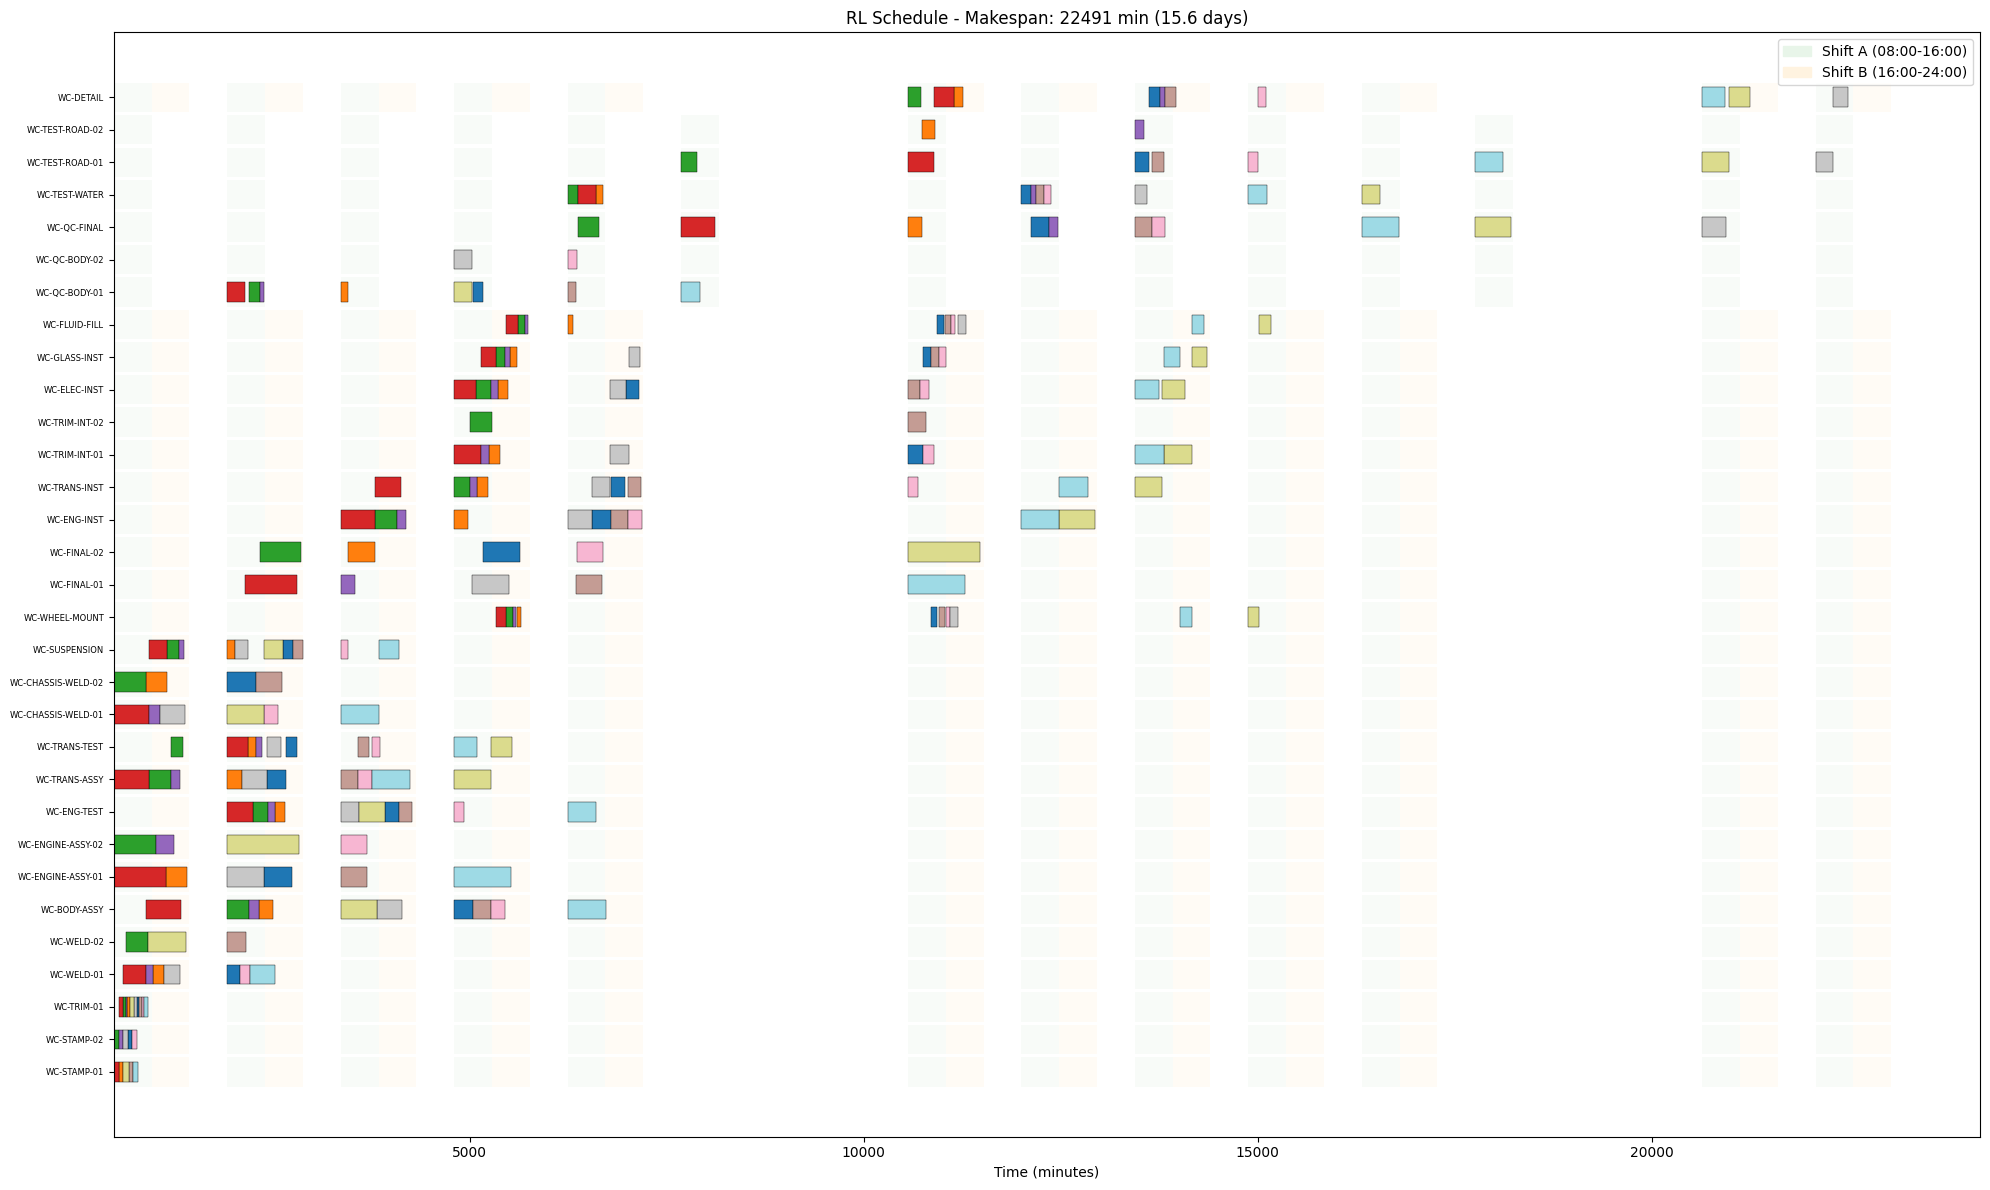

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
model, env = train_rl_scheduler()

# Evaluate trained model
obs, _ = env.reset(options={'new_instance': True})
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)

morning = sum(1 for st in env.scheduled if st and (st.start % 1440) < 960)
afternoon = sum(1 for st in env.scheduled if st and (st.start % 1440) >= 960)

print(f'\n{"="*50}')
print(f'📊 TRAINED MODEL RESULTS')
print(f'{"="*50}')
print(f'Scheduled: {env.n_scheduled}/{env.n_tasks}')
print(f'Makespan: {env.current_makespan} min ({env.current_makespan/1440:.1f} days)')
print(f'Shift A: {morning}, Shift B: {afternoon}')

# Show quantities
print(f'\nPO quantities:')
for job in env.jobs:
    print(f'  PO-{job[0].job_id}: qty={job[0].quantity}')

# Machine speed check
faster = slower = 0
for g_idx, st in enumerate(env.scheduled):
    if st is None: continue
    task = env.all_tasks[g_idx]
    alt_wcs = env.op_to_wc.get(task.operation_id, [])
    if len(alt_wcs) <= 1: continue
    pts = {wc: env.proc_times.get((g_idx, wc), 9999) for wc in alt_wcs if (g_idx, wc) in env.proc_times}
    if pts:
        chosen_pt = env.proc_times.get((g_idx, st.machine_id), 9999)
        if chosen_pt == min(pts.values()): faster += 1
        else: slower += 1
print(f'\n🏎️ Machine speed: Fastest={faster}, Slower={slower}')
if faster + slower > 0:
    print(f'   Accuracy: {faster/(faster+slower)*100:.1f}%')

env.render()

## Compare: Trained vs Random

In [9]:
# Run comparison on same instance
n_compare = 5
rl_makespans = []
rand_makespans = []

for i in range(n_compare):
    test_env = JSSPEnv(generator_seed=1000 + i)

    # RL agent
    obs, _ = test_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = test_env.step(action)
    rl_makespans.append(test_env.current_makespan)

    # Random agent (same instance)
    obs, _ = test_env.reset()
    done = False
    while not done:
        action = test_env.action_space.sample()
        obs, reward, done, _, info = test_env.step(action)
    rand_makespans.append(test_env.current_makespan)

print(f'\n{"="*50}')
print(f'📊 RL vs Random ({n_compare} instances)')
print(f'{"="*50}')
for i in range(n_compare):
    improvement = (rand_makespans[i] - rl_makespans[i]) / rand_makespans[i] * 100
    print(f'  Instance {i+1}: RL={rl_makespans[i]/1440:.1f}d, '
          f'Random={rand_makespans[i]/1440:.1f}d, '
          f'Improvement={improvement:.1f}%')
print(f'\n  Avg RL: {np.mean(rl_makespans)/1440:.1f} days')
print(f'  Avg Random: {np.mean(rand_makespans)/1440:.1f} days')
avg_imp = (np.mean(rand_makespans) - np.mean(rl_makespans)) / np.mean(rand_makespans) * 100
print(f'  Avg Improvement: {avg_imp:.1f}%')


📊 RL vs Random (5 instances)
  Instance 1: RL=21.7d, Random=21.6d, Improvement=-0.2%
  Instance 2: RL=60.3d, Random=60.4d, Improvement=0.0%
  Instance 3: RL=60.4d, Random=60.4d, Improvement=0.0%
  Instance 4: RL=18.6d, Random=60.4d, Improvement=69.2%
  Instance 5: RL=60.4d, Random=60.4d, Improvement=0.0%

  Avg RL: 44.3 days
  Avg Random: 52.6 days
  Avg Improvement: 15.9%
